# Greedy Tracking Portfolio for S&P 500

This notebook builds a sparse tracking portfolio from S&P 500 constituents using **three greedy stock selection methods**:

1. **Greedy TE Minimization**: At each step, add the stock that most reduces tracking error on the selection period.
2. **Greedy Correlation + Diversity**: At each step, add the stock with highest benchmark correlation penalized by average correlation to already-selected stocks.
3. **Greedy Beta Matching**: At each step, add the stock whose beta most reduces the gap between portfolio beta and benchmark beta (1.0).

Evaluates k = 10 to 100, fits long-only weights, and reports:
- Holdout tracking error
- Information ratio
- Sector drift vs S&P 500

In [ ]:
!pip -q install cvxpy yfinance tqdm lxml html5lib beautifulsoup4

In [ ]:
import os
import warnings
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display

import cvxpy as cp
import yfinance as yf

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_DIR        = Path('/content/drive/MyDrive/Mega')
CACHE_DIR       = Path('/content/drive/MyDrive/Mega/cache')
SECTOR_CACHE    = CACHE_DIR / 'sector_map.csv'
MARKETCAP_CACHE = CACHE_DIR / 'market_caps.csv'

FIT_START  = '2020-01-01'
FIT_END    = '2024-12-31'
SEL_START  = '2025-01-01'
SEL_END    = '2025-06-30'
HOLD_START = '2025-07-01'
HOLD_END   = '2025-12-31'

K_LIST = list(range(10, 101))  # k = 10 to 100
L2     = 1e-6

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
except Exception as e:
    print('Drive mount skipped:', e)

CACHE_DIR.mkdir(parents=True, exist_ok=True)
print('Data dir exists:', DATA_DIR.exists())
print('Example files:', [p.name for p in list(DATA_DIR.rglob('*.csv'))[:5]])

Mounted at /content/drive
Data dir exists: True
Example files: ['sp500_tickers_cache.csv', 'ABNB.csv', 'APP.csv', 'CARR.csv', 'CEG.csv']


In [ ]:
def load_ticker_cache(data_dir: Path, cache_name: str = 'sp500_tickers_cache.csv') -> pd.Series:
    cache_path = next(data_dir.rglob(cache_name), None)
    if cache_path is None:
        raise FileNotFoundError(f'{cache_name} not found under {data_dir}.')
    cache_df = pd.read_csv(cache_path)
    if cache_df.shape[1] != 1:
        raise ValueError(f'{cache_name} must have exactly one column, found {cache_df.shape[1]}')
    cache_col = cache_df.columns[0]
    tickers = cache_df[cache_col].astype(str).str.strip()
    tickers = tickers[tickers.ne('')].drop_duplicates().reset_index(drop=True)
    print(f'Tickers in cache: {len(tickers)}')
    return tickers


def load_price_panel(data_dir: Path, benchmark_stems=('^GSPC', 'GSPC'), cache_name='sp500_tickers_cache.csv'):
    if not data_dir.exists():
        raise FileNotFoundError(f'Data directory does not exist: {data_dir}')

    all_csvs = sorted(data_dir.rglob('*.csv'))
    benchmark_path = next((p for p in all_csvs if p.stem in benchmark_stems), None)
    if benchmark_path is None:
        raise FileNotFoundError(f'Benchmark file not found under {data_dir}')

    bench_df  = pd.read_csv(benchmark_path, parse_dates=['Date'])
    bench_df  = bench_df.sort_values('Date').drop_duplicates('Date', keep='last')
    benchmark = bench_df.set_index('Date')['Close'].astype(float).rename('benchmark').sort_index()

    stock_series, loaded, skipped = [], [], []
    for fp in all_csvs:
        if fp.name in {cache_name, benchmark_path.name}:
            continue
        ticker = fp.stem
        try:
            df = pd.read_csv(fp, parse_dates=['Date'])
        except Exception as e:
            skipped.append(ticker); continue
        if 'Date' not in df.columns:
            skipped.append(ticker); continue
        df = df.sort_values('Date').drop_duplicates('Date', keep='last')
        price_col = 'Adj Close' if 'Adj Close' in df.columns else ('Close' if 'Close' in df.columns else None)
        if price_col is None:
            skipped.append(ticker); continue
        s = df.set_index('Date')[price_col].astype(float).rename(ticker).sort_index()
        if s.notna().sum() < 50:
            skipped.append(ticker); continue
        stock_series.append(s)
        loaded.append(ticker)

    prices = pd.concat(stock_series, axis=1).sort_index()
    common = prices.index.intersection(benchmark.index)
    prices    = prices.loc[common].replace([np.inf, -np.inf], np.nan)
    benchmark = benchmark.loc[common]
    prices    = prices.loc[benchmark.notna()]
    benchmark = benchmark.loc[benchmark.notna()]

    print(f'Loaded: {len(loaded)} stocks | Skipped: {len(skipped)} | Price panel: {prices.shape}')
    return prices, benchmark


sp500_tickers        = load_ticker_cache(DATA_DIR)
prices, benchmark    = load_price_panel(DATA_DIR)

Tickers in cache: 503
Loaded: 578 stocks | Skipped: 7 | Price panel: (1525, 578)


In [ ]:
bench_ret    = benchmark.pct_change().rename('benchmark_ret')
stock_rets   = prices.pct_change()
aligned      = stock_rets.join(bench_ret, how='inner').dropna(subset=['benchmark_ret'])
stock_ret_df = aligned.drop(columns=['benchmark_ret'])
bench_ret    = aligned['benchmark_ret']

print('Return matrix:', stock_ret_df.shape)
print('Date range:', stock_ret_df.index.min().date(), '->', stock_ret_df.index.max().date())

Return matrix: (1524, 578)
Date range: 2020-01-03 -> 2026-01-27


In [ ]:
pre_holdout_mask = (stock_ret_df.index >= FIT_START) & (stock_ret_df.index <= SEL_END)
coverage         = stock_ret_df.loc[pre_holdout_mask].notna().mean().sort_values(ascending=False)
eligible_tickers = coverage[coverage >= 0.95].index.tolist()
print('Eligible tickers:', len(eligible_tickers))

X_all = stock_ret_df[eligible_tickers].copy()
y_all = bench_ret.loc[X_all.index].copy()

fit_mask  = (X_all.index >= FIT_START)  & (X_all.index <= FIT_END)
sel_mask  = (X_all.index >= SEL_START)  & (X_all.index <= SEL_END)
hold_mask = (X_all.index >= HOLD_START) & (X_all.index <= HOLD_END)

X_fit_raw  = X_all.loc[fit_mask];   y_fit  = y_all.loc[fit_mask]
X_sel_raw  = X_all.loc[sel_mask];   y_sel  = y_all.loc[sel_mask]
X_hold_raw = X_all.loc[hold_mask];  y_hold = y_all.loc[hold_mask]

usable_cols = X_fit_raw.columns[X_fit_raw.notna().any(axis=0)].tolist()
X_fit_raw   = X_fit_raw[usable_cols]
X_sel_raw   = X_sel_raw[usable_cols]
X_hold_raw  = X_hold_raw[usable_cols]

imputer  = SimpleImputer(strategy='median')
X_fit    = pd.DataFrame(imputer.fit_transform(X_fit_raw),  index=X_fit_raw.index,  columns=X_fit_raw.columns)
X_sel    = pd.DataFrame(imputer.transform(X_sel_raw),      index=X_sel_raw.index,  columns=X_sel_raw.columns)
X_hold   = pd.DataFrame(imputer.transform(X_hold_raw),     index=X_hold_raw.index, columns=X_hold_raw.columns)

print('Fit:', X_fit.shape, '| Selection:', X_sel.shape, '| Holdout:', X_hold.shape)

Eligible tickers: 559
Fit: (1257, 559) | Selection: (122, 559) | Holdout: (128, 559)


## Greedy Selection Methods

### Method 1 — Greedy TE Minimization
Iteratively adds the stock that most reduces tracking error (std of active returns) on the **selection period**.

### Method 2 — Greedy Correlation + Diversity
At each step picks the stock with: `score = bench_corr - 0.3 * avg_corr_to_selected`. High benchmark correlation + low redundancy with already-chosen stocks.

### Method 3 — Greedy Beta Matching
At each step picks the stock whose inclusion moves the equal-weight portfolio beta closest to 1.0 (the benchmark beta).

In [ ]:
bench_corr = X_sel.corrwith(y_sel).fillna(0.0)           # correlation with benchmark
bench_var  = y_sel.var(ddof=1)
stock_cov  = X_sel.cov()                                  # stock-stock covariance

# Beta = cov(stock, benchmark) / var(benchmark)
stock_beta = X_sel.apply(lambda col: col.cov(y_sel) / (bench_var + 1e-12))

print('Benchmark correlation range:', round(bench_corr.min(), 3), '->', round(bench_corr.max(), 3))
print('Stock beta range:', round(stock_beta.min(), 3), '->', round(stock_beta.max(), 3))

Benchmark correlation range: -0.204 -> 0.91
Stock beta range: -0.229 -> 2.464


In [ ]:
def greedy_te(X_sel, y_sel, k):
    """Method 1: greedily add stock that most reduces tracking error."""
    candidates = list(X_sel.columns)
    selected   = []

    for _ in range(k):
        best_stock, best_te = None, np.inf
        for stock in candidates:
            trial = selected + [stock]
            # Equal-weight trial portfolio
            rp     = X_sel[trial].mean(axis=1)
            active = rp - y_sel
            te     = active.std(ddof=1)
            if te < best_te:
                best_te, best_stock = te, stock
        selected.append(best_stock)
        candidates.remove(best_stock)

    return selected


def greedy_corr_diversity(X_sel, y_sel, bench_corr, k, diversity_penalty=0.3):
    """Method 2: high benchmark corr, penalized by redundancy with selected."""
    candidates = list(X_sel.columns)
    selected   = []

    for _ in range(k):
        best_stock, best_score = None, -np.inf
        for stock in candidates:
            bc = bench_corr.loc[stock]
            if selected:
                avg_corr = X_sel[selected].corrwith(X_sel[stock]).abs().mean()
            else:
                avg_corr = 0.0
            score = bc - diversity_penalty * avg_corr
            if score > best_score:
                best_score, best_stock = score, stock
        selected.append(best_stock)
        candidates.remove(best_stock)

    return selected


def greedy_beta_match(X_sel, y_sel, stock_beta, k):
    """Method 3: greedily add stock that brings equal-weight portfolio beta closest to 1.0."""
    candidates = list(X_sel.columns)
    selected   = []

    for step in range(k):
        best_stock, best_gap = None, np.inf
        for stock in candidates:
            trial      = selected + [stock]
            port_beta  = np.mean([stock_beta.loc[t] for t in trial])
            gap        = abs(port_beta - 1.0)
            if gap < best_gap:
                best_gap, best_stock = gap, stock
        selected.append(best_stock)
        candidates.remove(best_stock)

    return selected


print('Greedy functions defined.')

Greedy functions defined.


In [ ]:
def fit_simplex_weights(X_train: pd.DataFrame, y_train: pd.Series, l2=1e-6):
    """Long-only simplex weight optimization (sum=1, w>=0)."""
    idx     = X_train.index.intersection(y_train.index)
    X_train = X_train.loc[idx]; y_train = y_train.loc[idx]
    Xv, yv  = X_train.values.astype(float), y_train.values.astype(float)
    k       = Xv.shape[1]
    w       = cp.Variable(k, nonneg=True)
    prob    = cp.Problem(
        cp.Minimize(cp.sum_squares(Xv @ w - yv) + l2 * cp.sum_squares(w)),
        [cp.sum(w) == 1]
    )
    for solver in [cp.OSQP, cp.ECOS, cp.SCS]:
        try:
            prob.solve(solver=solver, verbose=False)
            if w.value is not None:
                break
        except Exception:
            continue
    if w.value is None:
        return pd.Series(np.ones(k) / k, index=X_train.columns)
    ww = np.clip(w.value, 0, None)
    ww = ww / ww.sum()
    return pd.Series(ww, index=X_train.columns)


def compute_metrics(X, y, weights):
    idx    = X.index.intersection(y.index)
    cols   = X.columns.intersection(weights.index)
    rp     = X.loc[idx, cols].mul(weights[cols], axis=1).sum(axis=1)
    active = rp - y.loc[idx]
    te     = active.std(ddof=1) * np.sqrt(252)
    ir     = (active.mean() / (active.std(ddof=1) + 1e-12)) * np.sqrt(252)
    return te, ir


def evaluate_subset(subset, X_fit, y_fit, X_sel, y_sel, X_hold, y_hold):
    X_train = pd.concat([X_fit[subset], X_sel[subset]])
    y_train = pd.concat([y_fit, y_sel])
    w       = fit_simplex_weights(X_train, y_train)
    fit_te,  fit_ir  = compute_metrics(X_fit,  y_fit,  w)
    sel_te,  sel_ir  = compute_metrics(X_sel,  y_sel,  w)
    hold_te, hold_ir = compute_metrics(X_hold, y_hold, w)
    return dict(weights=w, fit_te=fit_te, sel_te=sel_te, hold_te=hold_te,
                fit_ir=fit_ir, sel_ir=sel_ir, hold_ir=hold_ir)


print('Weight optimization and evaluation functions defined.')

Weight optimization and evaluation functions defined.


In [ ]:
# Pre-build greedy orderings up to k=100 (run once, slice for each k)
# Method 1 is O(N*k) so we run it up to k=100 once
print('Building greedy TE ordering (slow — O(N*k))...')
greedy_te_order = greedy_te(X_sel, y_sel, k=100)
print('Done. Top 10:', greedy_te_order[:10])

print('Building greedy correlation+diversity ordering...')
greedy_cd_order = greedy_corr_diversity(X_sel, y_sel, bench_corr, k=100)
print('Done. Top 10:', greedy_cd_order[:10])

print('Building greedy beta-matching ordering...')
greedy_bm_order = greedy_beta_match(X_sel, y_sel, stock_beta, k=100)
print('Done. Top 10:', greedy_bm_order[:10])

Building greedy TE ordering (slow — O(N*k))...
Done. Top 10: ['AME', 'MSFT', 'MCO', 'CSCO', 'AMZN', 'PEG', 'AAPL', 'V', 'DOV', 'GOOG']
Building greedy correlation+diversity ordering...
Done. Top 10: ['AXP', 'TRMB', 'PH', 'BLK', 'EMR', 'GS', 'DOV', 'TROW', 'MCO', 'AMZN']
Building greedy beta-matching ordering...
Done. Top 10: ['LII', 'TT', 'PNC', 'GOOG', 'HLT', 'RRC', 'JPM', 'GOOGL', 'FSLR', 'WDAY']


In [ ]:
all_rows     = []
weight_store = {}

METHOD_ORDERS = {
    'greedy_te':          greedy_te_order,
    'greedy_corr_div':    greedy_cd_order,
    'greedy_beta':        greedy_bm_order,
}

for k in tqdm(K_LIST, desc='Evaluating k'):
    for method, order in METHOD_ORDERS.items():
        subset  = order[:k]
        metrics = evaluate_subset(subset, X_fit, y_fit, X_sel, y_sel, X_hold, y_hold)
        all_rows.append(dict(
            k=k, method=method, n_selected=len(subset),
            fit_te_ann=metrics['fit_te'],   sel_te_ann=metrics['sel_te'],   hold_te_ann=metrics['hold_te'],
            fit_ir_ann=metrics['fit_ir'],   sel_ir_ann=metrics['sel_ir'],   hold_ir_ann=metrics['hold_ir'],
        ))
        weight_store[(method, k)] = metrics['weights']

results = pd.DataFrame(all_rows).sort_values(['method', 'k']).reset_index(drop=True)
print('Results shape:', results.shape)
results.head()

Evaluating k:   0%|          | 0/91 [00:00<?, ?it/s]

Results shape: (273, 9)


,k,method,n_selected,fit_te_ann,sel_te_ann,hold_te_ann,fit_ir_ann,sel_ir_ann,hold_ir_ann
0,10,greedy_beta,10,0.096769,0.088015,0.096715,1.066424,-0.074072,1.662135
1,11,greedy_beta,11,0.092811,0.083458,0.091338,1.099093,-0.308639,1.506930
2,12,greedy_beta,12,0.091994,0.081477,0.090083,1.031109,-0.201380,1.444021
3,13,greedy_beta,13,0.091994,0.081477,0.090083,1.031109,-0.201380,1.444021
4,14,greedy_beta,14,0.091994,0.081477,0.090083,1.031109,-0.201380,1.444021


In [ ]:
# Summary pivot table
pivot = results.pivot(index='k', columns='method', values=['hold_te_ann', 'hold_ir_ann'])
pivot.round(4)

hold_te_ann                           hold_ir_ann                  \
method greedy_beta greedy_corr_div greedy_te greedy_beta greedy_corr_div   
k                                                                          
10          0.0967          0.1011    0.0639      1.6621         -0.4725   
11          0.0913          0.0973    0.0640      1.5069          0.3903   
12          0.0901          0.0973    0.0633      1.4440          0.3903   
13          0.0901          0.0976    0.0583      1.4440          0.2110   
14          0.0901          0.0949    0.0590      1.4440          0.5686   
..             ...             ...       ...         ...             ...   
96          0.0559          0.0553    0.0330     -0.7231          0.1591   
97          0.0559          0.0552    0.0330     -0.7464          0.1538   
98          0.0559          0.0552    0.0329     -0.7464          0.0116   
99          0.0557          0.0552    0.0330     -0.7977          0.0116   
100         0.0563          0.0552    0.0329     -1.2871          0.0116   

                  
method greedy_te  
k                 
10        0.2944  
11        0.2030  
12        0.2271  
13        0.2653  
14       -0.2455  
..           ...  
96        0.2246  
97        0.2246  
98        0.2162  
99        0.2106  
100       0.1424  

[91 rows x 6 columns]

In [ ]:
# Best k and top stocks per method
for method in METHOD_ORDERS.keys():
    sub      = results[(results['method'] == method) & (results['k'] <= 50)].copy()
    best_row = sub.loc[sub['hold_te_ann'].idxmin()]
    k        = int(best_row['k'])
    w        = weight_store[(method, k)]

    df = pd.DataFrame({'ticker': w.index, 'weight': w.values}).sort_values('weight', ascending=False)

    print(f'\n{"="*55}')
    print(f'  Method: {method.upper()}  |  Best k={k}')
    print(best_row.to_string())
    print(f'{"="*55}')
    display(df.head(20))

# Set best_k and best_weights to greedy_te for downstream cells
sub_best  = results[(results['method'] == 'greedy_te') & (results['k'] <= 50)].copy()
best_row  = sub_best.loc[sub_best['hold_te_ann'].idxmin()]
best_k    = int(best_row['k'])
best_weights = weight_store[('greedy_te', best_k)]


  Method: GREEDY_TE  |  Best k=48
k                     48
method         greedy_te
n_selected            48
fit_te_ann      0.026204
sel_te_ann      0.021154
hold_te_ann     0.034186
fit_ir_ann      3.021221
sel_ir_ann      2.611675
hold_ir_ann    -0.857978


,ticker,weight
22,BRK-B,0.069561
1,MSFT,0.065089
6,AAPL,0.064494
15,COST,0.041501
8,DOV,0.039692
38,GOOGL,0.036158
4,AMZN,0.035748
39,D,0.034853
44,VZ,0.034850
7,V,0.032242



  Method: GREEDY_CORR_DIV  |  Best k=50
k                           50
method         greedy_corr_div
n_selected                  50
fit_te_ann            0.052117
sel_te_ann            0.068752
hold_te_ann           0.059687
fit_ir_ann            1.213917
sel_ir_ann            0.335792
hold_ir_ann           1.581562


,ticker,weight
28,AAPL,0.127483
19,CSCO,0.115784
9,AMZN,0.096855
23,NDAQ,0.093335
42,JPM,0.078772
32,AME,0.074420
8,MCO,0.058342
25,ISRG,0.047305
6,DOV,0.042109
45,CAT,0.036073



  Method: GREEDY_BETA  |  Best k=50
k                       50
method         greedy_beta
n_selected              50
fit_te_ann         0.04989
sel_te_ann        0.047772
hold_te_ann       0.056828
fit_ir_ann        1.442893
sel_ir_ann        1.239494
hold_ir_ann      -0.320244


,ticker,weight
38,MSFT,0.189667
6,JPM,0.064936
30,NDAQ,0.059879
7,GOOGL,0.059021
20,DHR,0.051249
42,PLD,0.046103
26,BK,0.044682
1,TT,0.039216
47,GEN,0.035369
49,NFLX,0.033318


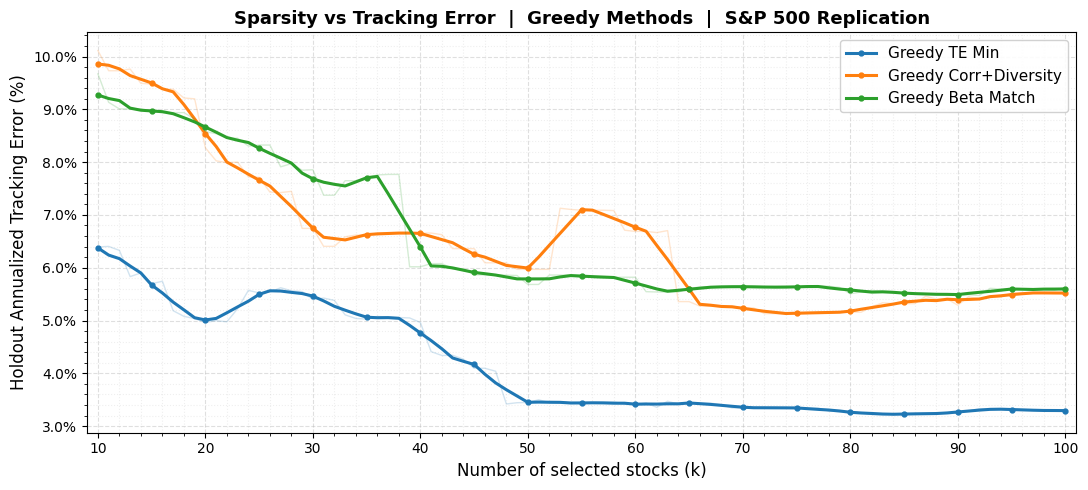

In [ ]:
COLORS = {'greedy_te': '#1f77b4', 'greedy_corr_div': '#ff7f0e', 'greedy_beta': '#2ca02c'}
LABELS = {'greedy_te': 'Greedy TE Min', 'greedy_corr_div': 'Greedy Corr+Diversity', 'greedy_beta': 'Greedy Beta Match'}
WINDOW = 5

fig, ax = plt.subplots(figsize=(11, 5))
for method in METHOD_ORDERS.keys():
    sub      = results[results['method'] == method].sort_values('k')
    raw      = sub['hold_te_ann'].values
    k        = sub['k'].values
    smoothed = pd.Series(raw).rolling(WINDOW, center=True, min_periods=1).mean().values
    ax.plot(k, raw * 100,      color=COLORS[method], alpha=0.20, linewidth=1)
    ax.plot(k, smoothed * 100, color=COLORS[method], linewidth=2.2,
            label=LABELS[method], marker='o', markersize=3.5, markevery=5)

ax.set_xlabel('Number of selected stocks (k)', fontsize=12)
ax.set_ylabel('Holdout Annualized Tracking Error (%)', fontsize=12)
ax.set_title('Sparsity vs Tracking Error  |  Greedy Methods  |  S&P 500 Replication', fontsize=13, fontweight='bold')
ax.set_xlim(9, 101)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}%'))
ax.xaxis.set_major_locator(plt.MultipleLocator(10))
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(True, which='major', linestyle='--', alpha=0.4)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)
ax.minorticks_on()
plt.tight_layout()
plt.show()

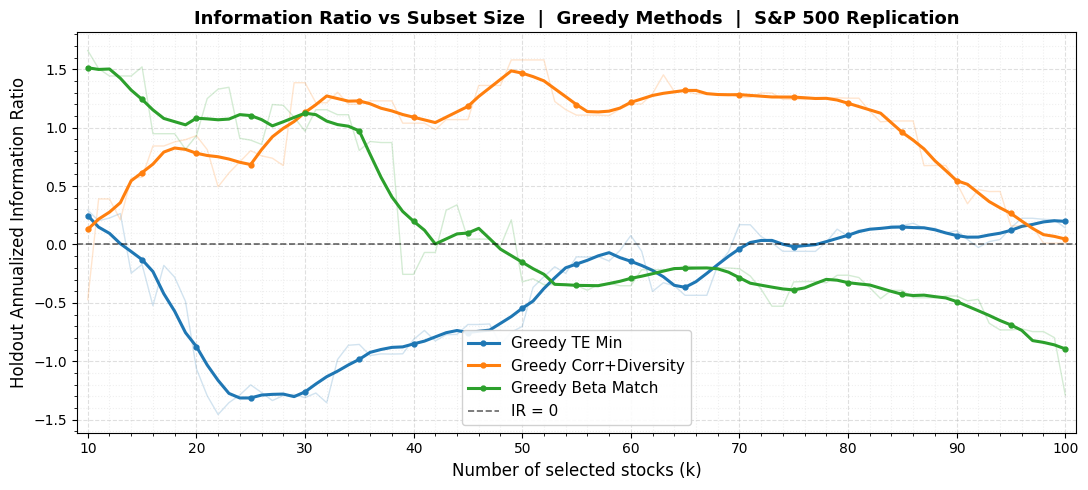

In [ ]:
WINDOW = 7
fig, ax = plt.subplots(figsize=(11, 5))
for method in METHOD_ORDERS.keys():
    sub      = results[results['method'] == method].sort_values('k')
    raw      = sub['hold_ir_ann'].values
    k        = sub['k'].values
    smoothed = pd.Series(raw).rolling(WINDOW, center=True, min_periods=1).mean().values
    ax.plot(k, raw,      color=COLORS[method], alpha=0.20, linewidth=1)
    ax.plot(k, smoothed, color=COLORS[method], linewidth=2.2,
            label=LABELS[method], marker='o', markersize=3.5, markevery=5)

ax.axhline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.6, label='IR = 0')
ax.set_xlabel('Number of selected stocks (k)', fontsize=12)
ax.set_ylabel('Holdout Annualized Information Ratio', fontsize=12)
ax.set_title('Information Ratio vs Subset Size  |  Greedy Methods  |  S&P 500 Replication', fontsize=13, fontweight='bold')
ax.set_xlim(9, 101)
ax.xaxis.set_major_locator(plt.MultipleLocator(10))
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(True, which='major', linestyle='--', alpha=0.4)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)
ax.minorticks_on()
plt.tight_layout()
plt.show()

Loaded sector map from cache (unknown rate: 0.9%)
Loaded market caps from cache
Sector weight mode: market-cap weighted


,market_cap
sector,
Technology,0.302430
Communication Services,0.164532
Financial Services,0.121099
Consumer Cyclical,0.096971
Healthcare,0.087617
Industrials,0.073892
Consumer Defensive,0.056540
Energy,0.036462
Utilities,0.021816


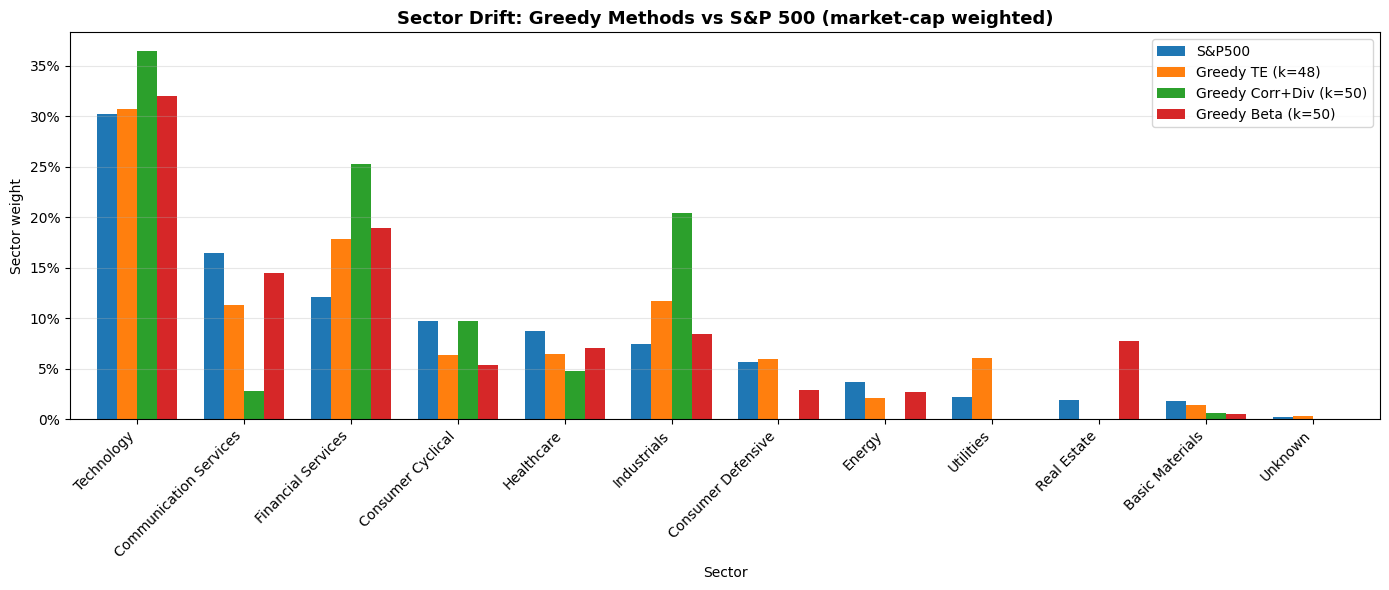

,S&P500,Greedy TE (k=48),Greedy Corr+Div (k=50),Greedy Beta (k=50)
sector,,,,
Technology,0.3024,0.3069,0.3649,0.3205
Communication Services,0.1645,0.1127,0.0280,0.1450
Financial Services,0.1211,0.1784,0.2529,0.1894
Consumer Cyclical,0.0970,0.0638,0.0969,0.0537
Healthcare,0.0876,0.0641,0.0473,0.0702
Industrials,0.0739,0.1171,0.2042,0.0840
Consumer Defensive,0.0565,0.0596,0.0000,0.0283
Energy,0.0365,0.0208,0.0000,0.0270
Utilities,0.0218,0.0604,0.0000,0.0000


In [ ]:
# Sector drift plot — all 3 methods vs S&P 500

def get_sp500_sector_map(tickers, cache_path: Path, max_workers: int = 16):
    if cache_path.exists():
        cached = pd.read_csv(cache_path)
        if set(tickers).issubset(set(cached['ticker'])):
            unknown_rate = (cached['sector'] == 'Unknown').mean()
            if unknown_rate < 0.10:
                print(f'Loaded sector map from cache (unknown rate: {unknown_rate:.1%})')
                return cached
            else:
                print(f'Cache stale ({unknown_rate:.1%} unknown), refetching...')

    sector_map = {}
    try:
        tables  = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')
        wiki    = tables[0]
        sym_col = [c for c in wiki.columns if 'symbol' in c.lower() or 'ticker' in c.lower()][0]
        sec_col = [c for c in wiki.columns if 'gics sector' in c.lower() or 'sector' in c.lower()][0]
        for _, row in wiki.iterrows():
            sym = str(row[sym_col]).strip().replace('.', '-')
            sector_map[sym] = str(row[sec_col]).strip()
        print(f'Wikipedia: mapped {len(sector_map)} tickers')
    except Exception as e:
        print(f'Wikipedia failed: {e}')

    still_unknown = [t for t in tickers if sector_map.get(t, 'Unknown') == 'Unknown']
    if still_unknown:
        def fetch_yf(t):
            try:
                return t, yf.Ticker(t).get_info().get('sector') or 'Unknown'
            except Exception:
                return t, 'Unknown'
        with ThreadPoolExecutor(max_workers=max_workers) as ex:
            futs = {ex.submit(fetch_yf, t): t for t in still_unknown}
            for fut in tqdm(as_completed(futs), total=len(futs), desc='yfinance fallback'):
                t, s = fut.result(); sector_map[t] = s

    df = pd.DataFrame([{'ticker': t, 'sector': sector_map.get(t, 'Unknown')} for t in tickers])
    print(f'Final unknown rate: {(df["sector"]=="Unknown").mean():.1%}')
    try:
        df.to_csv(cache_path, index=False)
    except Exception as e:
        print('Warning: could not save cache:', e)
    return df


def get_market_caps(tickers, cache_path: Path, max_workers: int = 16):
    if cache_path.exists():
        cached = pd.read_csv(cache_path)
        if set(tickers).issubset(set(cached['ticker'])):
            if cached['market_cap'].notna().mean() >= 0.5:
                print('Loaded market caps from cache')
                return cached
    def fetch_one(t):
        try:
            fi = getattr(yf.Ticker(t), 'fast_info', None)
            mc = getattr(fi, 'market_cap', np.nan) if fi is not None else np.nan
            if pd.isna(mc):
                mc = yf.Ticker(t).get_info().get('marketCap', np.nan)
        except Exception:
            mc = np.nan
        return {'ticker': t, 'market_cap': mc}
    rows = []
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futs = {ex.submit(fetch_one, t): t for t in tickers}
        for fut in tqdm(as_completed(futs), total=len(futs), desc='Fetching market caps'):
            rows.append(fut.result())
    out = pd.DataFrame(rows)
    try:
        out.to_csv(cache_path, index=False)
    except Exception as e:
        print('Warning: could not save cache:', e)
    return out


sector_df     = get_sp500_sector_map(eligible_tickers, SECTOR_CACHE)
universe_info = sector_df.copy()

try:
    mcap = get_market_caps(universe_info['ticker'].tolist(), MARKETCAP_CACHE)
    universe_info = universe_info.merge(mcap, on='ticker', how='left')
    valid = universe_info['market_cap'].notna().sum()
    if valid >= max(30, int(0.3 * len(universe_info))):
        universe_info['market_cap'] = universe_info.groupby('sector')['market_cap'].transform(
            lambda s: s.fillna(s.median())
        ).fillna(universe_info['market_cap'].median())
        sector_weights_true = universe_info.groupby('sector')['market_cap'].sum()
        sector_weights_true = sector_weights_true / sector_weights_true.sum()
        sector_weight_mode  = 'market-cap weighted'
    else:
        raise ValueError('Too many missing market caps')
except Exception as e:
    print('Market cap failed, using equal-weight proxy:', e)
    sector_weights_true = universe_info['sector'].value_counts(normalize=True)
    sector_weight_mode  = 'equal-weight proxy'

print('Sector weight mode:', sector_weight_mode)
display(sector_weights_true.sort_values(ascending=False).head(10))


def sector_weights_for(method, k_cap=50):
    sub  = results[(results['method'] == method) & (results['k'] <= k_cap)]
    k    = int(sub.loc[sub['hold_te_ann'].idxmin(), 'k'])
    w    = weight_store[(method, k)]
    df   = pd.DataFrame({'ticker': w.index, 'weight': w.values})
    df   = df.merge(universe_info[['ticker', 'sector']], on='ticker', how='left')
    df['sector'] = df['sector'].fillna('Unknown')
    return df.groupby('sector')['weight'].sum(), k


sw_te,   k_te   = sector_weights_for('greedy_te')
sw_cd,   k_cd   = sector_weights_for('greedy_corr_div')
sw_bm,   k_bm   = sector_weights_for('greedy_beta')

sector_compare = pd.DataFrame({
    'S&P500':                           sector_weights_true,
    f'Greedy TE (k={k_te})':            sw_te,
    f'Greedy Corr+Div (k={k_cd})':      sw_cd,
    f'Greedy Beta (k={k_bm})':          sw_bm,
}).fillna(0.0).sort_values('S&P500', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
sector_compare.plot(kind='bar', ax=ax, width=0.75)
ax.set_ylabel('Sector weight')
ax.set_xlabel('Sector')
ax.set_title(f'Sector Drift: Greedy Methods vs S&P 500 ({sector_weight_mode})', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.grid(True, axis='y', alpha=0.3)
plt.show()

sector_compare.round(4)